# Multinomial Logistic Regression From Scratch

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")
np.random.seed(42)

## Loading the Dataset

In [2]:
df = pd.read_csv("IRIS.csv")
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Data Exploration

In [3]:
df.shape

(150, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
df['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

## Data Preprocessing

**Checking for missing values**

In [7]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


**Handling missing values (if any were found above)**

In [8]:
if df.isnull().sum().sum() > 0:
    before = df.shape[0]
    df = df.dropna()
    print(f"Removed {before - df.shape[0]} rows containing missing values.")
    print(f"New shape: {df.shape}")
else:
    print("No missing values found. No action needed.")

No missing values found. No action needed.


**Checking for duplicate rows**

In [9]:
df.duplicated().sum()

np.int64(3)

**Handling duplicate rows (if any were found above)**

In [10]:
n_duplicates = df.duplicated().sum()

if n_duplicates > 0:
    before = df.shape[0]
    df = df.drop_duplicates()
    print(f"Removed {before - df.shape[0]} duplicate rows.")
    print(f"New shape: {df.shape}")
else:
    print("No duplicate rows found. No action needed.")

Removed 3 duplicate rows.
New shape: (147, 5)


**Encoding the target column**

`species` is text, so we map each unique species name to an integer class label (0, 1, 2).

In [11]:
species_mapping = {val: i for i, val in enumerate(df['species'].unique())}
print(f"Species mapping: {species_mapping}")

df['species_encoded'] = df['species'].map(species_mapping)
df[['species', 'species_encoded']].sample(5)

Species mapping: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


,species,species_encoded
127,Iris-virginica,2
53,Iris-versicolor,1
140,Iris-virginica,2
19,Iris-setosa,0
106,Iris-virginica,2


**Separating features and target**

In [12]:
x = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species_encoded']

In [13]:
x.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


**Train / Test Split**

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Data Analysis

**Target class distribution**

species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64


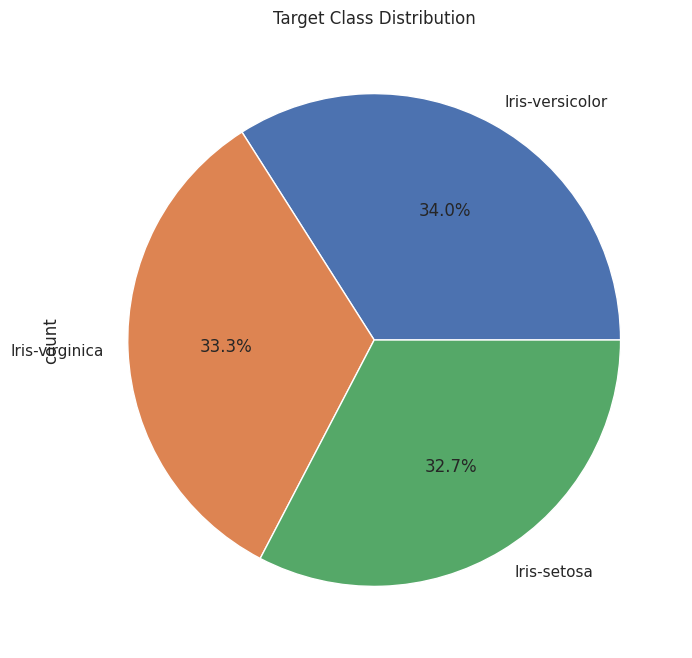

In [15]:
value_counts = df['species'].value_counts()
print(value_counts)
plt.figure(figsize=(8, 8))
value_counts.plot.pie(autopct='%1.1f%%')
plt.title('Target Class Distribution')
plt.show()

**Correlation heatmap**

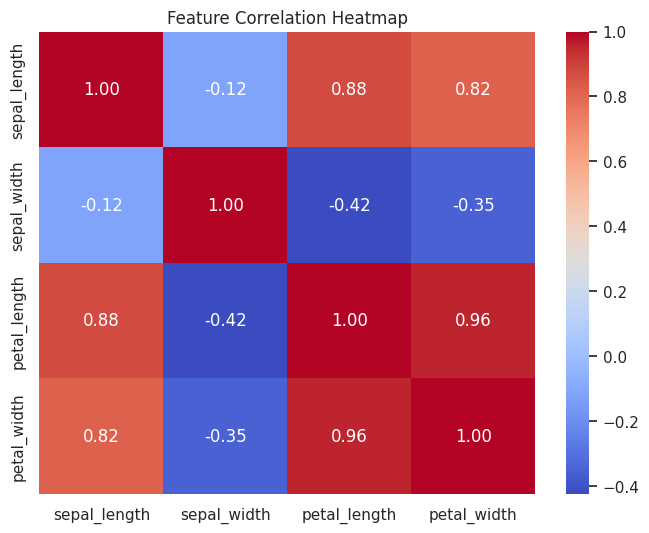

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(x_train.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

**Feature distributions by species**

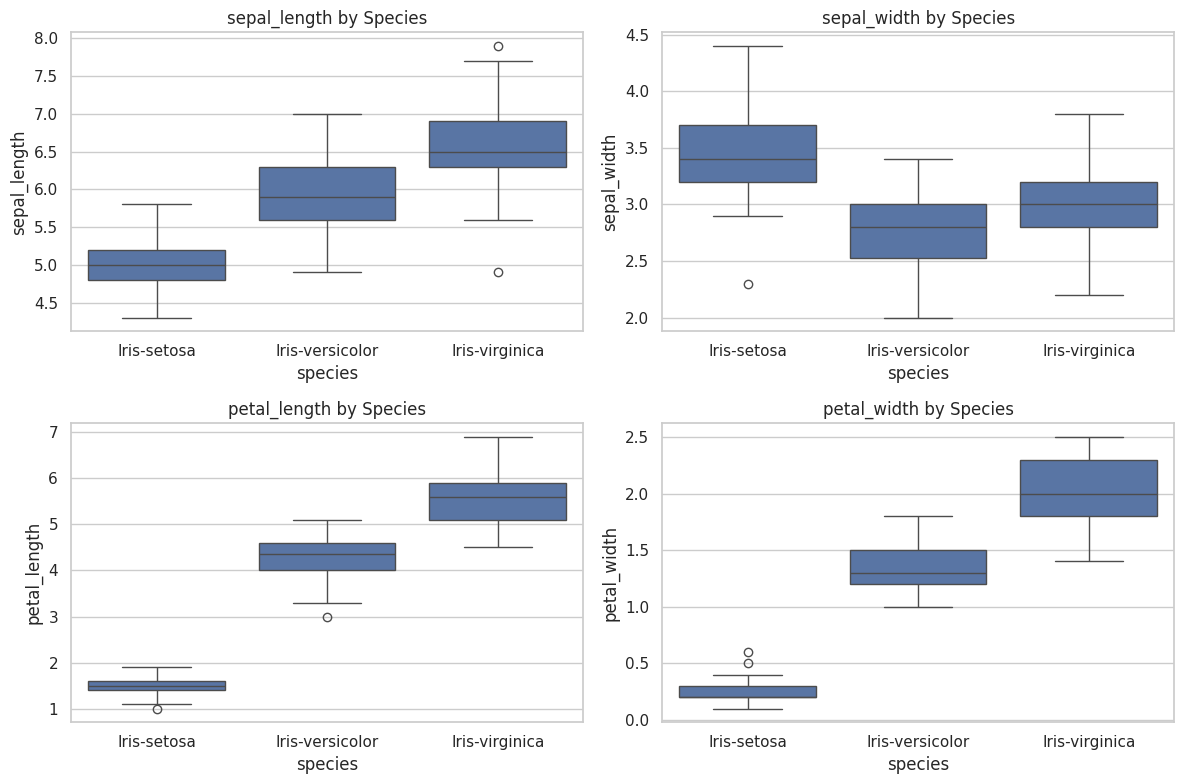

In [17]:
plt.figure(figsize=(12, 8))
for i, col in enumerate(x.columns):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df['species'], y=df[col])
    plt.title(f'{col} by Species')
plt.tight_layout()
plt.show()

**Converting to arrays**

Our from-scratch model works directly with NumPy arrays.

In [18]:
x_train = x_train.values
x_test = x_test.values
y_train = y_train.values
y_test = y_test.values

## Standardization

Standardizes features to zero mean and unit variance, fitting only on the training set to avoid data leakage.

In [19]:
x_mean = x_train.mean(axis=0)
x_std = x_train.std(axis=0)

x_train_scaled = (x_train - x_mean) / x_std
x_test_scaled = (x_test - x_mean) / x_std

In [20]:
x_train_scaled[:5]

array([[ 0.59486878,  0.05831127,  0.94250316,  0.76726863],
       [-1.60687754,  0.28572521, -1.38920785, -1.36694663],
       [-0.38368514, -0.62393057,  0.60127716,  1.03404553],
       [-0.8729621 ,  0.96796705, -1.33233685, -1.36694663],
       [-1.11760058,  1.195381  , -1.38920785, -1.36694663]])

## One-Hot Encoding Function

Converts integer class labels into one-hot vectors, needed to compute the cross-entropy loss against the softmax output.

In [21]:
def one_hot_encode(y, num_classes):
    m = len(y)
    one_hot = np.zeros((m, num_classes))
    one_hot[np.arange(m), y] = 1
    return one_hot

## Multinomial Logistic Regression — Implemented From Scratch

Uses the softmax function to turn raw class scores into probabilities, and gradient descent on categorical cross-entropy loss to learn the weights.

In [22]:
class MultinomialLogisticRegression:
    def __init__(self, learning_rate=0.1, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def _softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def fit(self, X, y_raw, num_classes):
        num_samples, num_features = X.shape

        Y = one_hot_encode(y_raw, num_classes)

        self.weights = np.zeros((num_features, num_classes))
        self.bias = np.zeros((1, num_classes))
        self.cost_history = []

        for i in range(self.iterations):
            # Compute raw scores (Z = XW + b)
            Z = np.dot(X, self.weights) + self.bias

            Y_pred = self._softmax(Z)

            # Adding a tiny epsilon (1e-15) prevents log(0), which causes NaNs
            epsilon = 1e-15
            Y_pred = np.clip(Y_pred, epsilon, 1 - epsilon)
            cost = -(1 / num_samples) * np.sum(Y * np.log(Y_pred))
            self.cost_history.append(cost)

            # Gradients
            dW = (1 / num_samples) * np.dot(X.T, (Y_pred - Y))
            dB = (1 / num_samples) * np.sum(Y_pred - Y, axis=0, keepdims=True)

            # Update weights and bias
            self.weights -= self.lr * dW
            self.bias -= self.lr * dB

            if i % 100 == 0:
                print(f"Iteration {i:4d} | Categorical Cross-Entropy Loss: {cost:.4f}")

    def predict_proba(self, X):
        """Outputs probability matrix of shape (num_samples, num_classes)"""
        Z = np.dot(X, self.weights) + self.bias
        return self._softmax(Z)

    def predict(self, X):
        """Outputs class labels (0, 1, or 2) by picking the index of maximum probability"""
        probabilities = self.predict_proba(X)
        return np.argmax(probabilities, axis=1)

## Training the Model

In [23]:
model = MultinomialLogisticRegression(learning_rate=0.1, iterations=1000)
model.fit(x_train_scaled, y_train, num_classes=3)

Iteration    0 | Categorical Cross-Entropy Loss: 1.0986
Iteration  100 | Categorical Cross-Entropy Loss: 0.3292
Iteration  200 | Categorical Cross-Entropy Loss: 0.2551
Iteration  300 | Categorical Cross-Entropy Loss: 0.2125
Iteration  400 | Categorical Cross-Entropy Loss: 0.1841
Iteration  500 | Categorical Cross-Entropy Loss: 0.1638
Iteration  600 | Categorical Cross-Entropy Loss: 0.1486
Iteration  700 | Categorical Cross-Entropy Loss: 0.1367
Iteration  800 | Categorical Cross-Entropy Loss: 0.1271
Iteration  900 | Categorical Cross-Entropy Loss: 0.1193


## Model Evaluation

In [24]:
predictions = model.predict(x_test_scaled)

acc = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average='weighted')

print(f"Test Accuracy: {acc:.4f}")
print(f"Test F1 Score: {f1:.4f}")

Test Accuracy: 0.9667
Test F1 Score: 0.9667


In [25]:
print("True Labels:      ", y_test)
print("Predicted Labels: ", predictions)

True Labels:       [2 1 2 0 2 0 1 0 1 0 0 1 2 1 2 1 0 1 2 0 0 2 0 2 1 0 1 2 1 0]
Predicted Labels:  [2 1 2 0 2 0 1 0 2 0 0 1 2 1 2 1 0 1 2 0 0 2 0 2 1 0 1 2 1 0]


## Visualization

**Cost curve over training iterations**

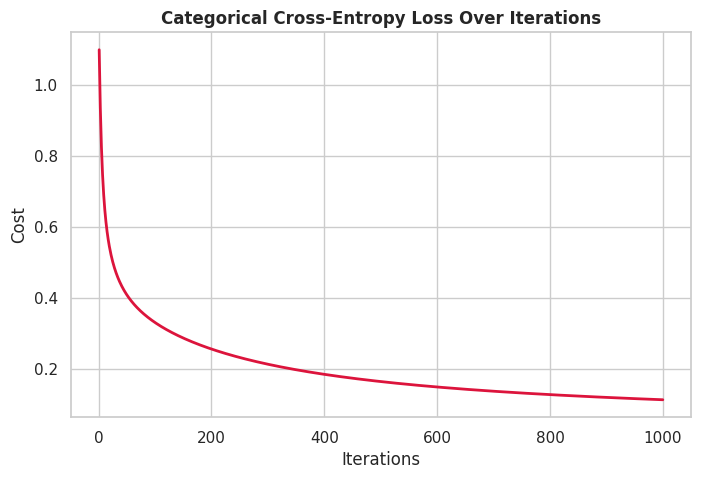

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, model.iterations + 1), model.cost_history, color='crimson', linewidth=2)
plt.title('Categorical Cross-Entropy Loss Over Iterations', fontweight='bold')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

**Confusion matrix**

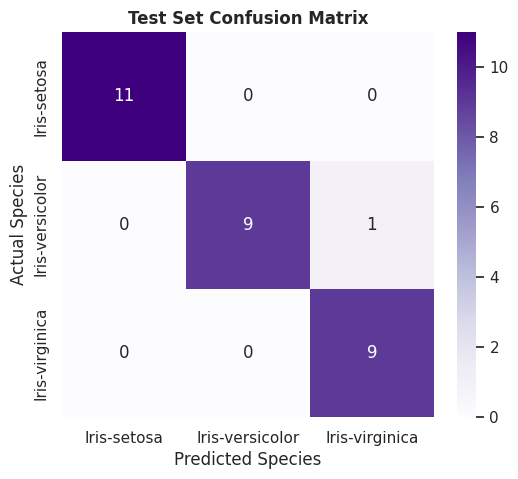

In [27]:
species_names = list(species_mapping.keys())
conf_matrix = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Purples',
            xticklabels=species_names, yticklabels=species_names)
plt.title('Test Set Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.show()